# Introduction

**Concept · Approach 1** <br>
Fit a *single GEV distribution* using annual maxima from **multiple years (pooled together)**, not separate GEVs for each year <br>
-> Separate analysis for different models and locations <br>


**Additional Notes**
- Using sim_year as the actual year 

**Notes on next steps:**
- 8 models × 680 locations = 5,440 independent analyses >> parallelize code on model level

Estimated Time
|Workers | Estimated Time | Speedup| 
|---| ---| ---| 
|1 core (sequential) | ~45-60 minutes | 1x baseline| 
|3 cores | ~15-20 minutes | ~3x faster| 
| 4 cores | ~12-15 minutes | ~4x faster|


**!!! ToDo**
- plot model fits
- create a mapping function for location info and lat/lon... store as JSON to save lookup
- analyze using all simulation at one location from all models (Approach2 - see email 26.01.26)


# Import Libraries

In [24]:
from typing import Optional
from glob import glob
import psutil
import multiprocessing as mp
import time
from datetime import datetime
from pathlib import Path

from pandas import concat
import random

import matplotlib.pyplot as plt

import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut
import func_gev as gev

# Settings

In [3]:
path = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/gev_analysis/'

In [4]:
hindcast_start = 1960
hindcast_end = 2019

In [22]:
return_periods = [10, 25, 50, 100, 200]
plot_period_evolution = ['10-year', '50-year', '100-year']

In [26]:
colors = [
    '#53354DFF','#7D4F73FF','#B887ADFF','#CAA5C2FF','#DBC3D6FF','#F5F5F5FF','#99E3DDFF',
    '#66D4CCFF','#33C6BBFF','#008A80FF','#005C55FF'
    ]

In [7]:
# For code parallelization later in the process 
print(f"Physical cores: {psutil.cpu_count(logical=False)}")
print(f"Logical cores: {psutil.cpu_count(logical=True)}")
print(f"Logical cores (mp): {mp.cpu_count()}")

Physical cores: 4
Logical cores: 8
Logical cores (mp): 8


# Import data

In [8]:
ls_files = [file for file in glob(path + '*.nc')]

test_models = ls_files[:3]

In [9]:
dic_data_per_model = dict()

for en, file in enumerate(test_models):
    model_name = file.split('/')[-1].split('.nc')[0].split('_')[-1]
    
    print(f'Importing data from model {model_name} ({en+1}/{len(ls_files)})...')
    model_name, ds_model = dbf.import_data_from_file(file) 
    
    dic_data_per_model[model_name] = dict({'raw data': ds_model})

Importing data from model MIROC6 (1/8)...
Importing data from model MPI-ESM1-2-HR (2/8)...
Importing data from model HadGEM3-GC31-MM (3/8)...


# Data Preparation 

BiasCorrection and Selection of valid data

In [10]:
en = 0 
for model_name, dic_data_model in dic_data_per_model.items():
    print(f'Processing model: {model_name} ({en+1}/{len(ls_files)})...')

    ds_model_corrected = dbf.bias_correction(dic_data_model['raw data'])
    dbf.verify_bias_correction(dic_data_model['raw data'], ds_model_corrected)
    print(f'\tBias correction successfully done and verified.')

    data_valid, sites_valid, sites_total, rate_invalid = dbf.select_valid_data(
        dic_data_model['raw data'], ds_model_corrected
    )
    print(
        f" - Site Selection done:\n"
        f"\tFrom {sites_total} sites, {sites_valid} are model_valid – removed {rate_invalid:.2f}% invalid sites."
    )
    
    dic_data_per_model[model_name]['valid data'] = data_valid
    dic_data_per_model[model_name]['preparation info'] = sites_valid, sites_total, rate_invalid
    en += 1
    print("-------------------------------------------------------------------------------------")
    print("")

Processing model: MIROC6 (1/8)...
 - Validating bias correction:
	Asserting whether actual ([1.19520299 1.31353562]) selection matches expected selection ([1.19520299 1.31353562])... 
	Bias correction successfully done and verified.
 - Site Selection done:
	From 11022 sites, 7054 are model_valid – removed 36.00% invalid sites.
-------------------------------------------------------------------------------------

Processing model: MPI-ESM1-2-HR (2/8)...
 - Validating bias correction:
	Asserting whether actual ([0.23771237 0.29686076]) selection matches expected selection ([0.23771237 0.29686076])... 
	Bias correction successfully done and verified.
 - Site Selection done:
	From 11022 sites, 5808 are model_valid – removed 47.31% invalid sites.
-------------------------------------------------------------------------------------

Processing model: HadGEM3-GC31-MM (3/8)...
 - Validating bias correction:
	Asserting whether actual ([0.21056422 0.21225497]) selection matches expected selectio

In [11]:
sites_valid = [dic_data_per_model[model_label]['preparation info'][0] for model_label in dic_data_per_model.keys()]

print("Data Overview")
print(
    f"Data is available from {len(test_models)} models (out of {len(ls_files)}) and "
    f"{min(sites_valid)}-{max(sites_valid)} locations"
    f""
)

Data Overview
Data is available from 3 models (out of 8) and 5808-7216 locations


Estimated processing time for 8 models: ~5min

# Workflow GEV - Generalized Extreme Value

## Initial try 

### Batch data to 5 locations all years

Create a batch of 5 locations. If this workflow works, we can batch and paralize the rest.

In [27]:
ls_models = list(dic_data_per_model.keys())
ls_models

['MIROC6', 'MPI-ESM1-2-HR', 'HadGEM3-GC31-MM']

In [13]:
dic_model_valid = dict(
    map(
        lambda ex_model: (ex_model, dic_data_per_model[ex_model]['valid data']),
        ls_models
    )
)

In [14]:
dic_locationsID_per_model = {}

for model_ in dic_model_valid.keys():
    locations_id = []
    while len(locations_id) < 5:
        locations_id.append(random.randint(0, dic_model_valid[model_].shape[-1]))    
    dic_locationsID_per_model[model_] = sorted(locations_id)
    
dic_locationsID_per_model

{'MIROC6': [1262, 2811, 3486, 3645, 4520],
 'MPI-ESM1-2-HR': [2167, 2182, 2729, 3066, 4372],
 'HadGEM3-GC31-MM': [1167, 1439, 1479, 3145, 6718]}

In [15]:
dic_batch_locations = {
    model_: dic_model_valid[model_][:, :, dic_locationsID_per_model[model_]] 
    for model_ in dic_model_valid.keys()
    }

In [16]:
dic_data = {}
df = None

for model_ in dic_batch_locations.keys():
    df = dic_batch_locations[model_].to_dataframe(name="value").reset_index()
    df['model'] = model_
    df.rename(columns={'value': 'storm_surge'}, inplace=True)
    dic_data[model_] = df
    
df = concat(dic_data).reset_index()

df.describe()

,level_1,sample,member,sites,sim_year,lead,lon,lat,bc_flag,storm_surge
count,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,16175.000000
mean,3320.354271,331.585427,1.500000,4767.375879,1995.291457,5.500000,11.892156,40.457408,2.731658,0.380116
std,1922.040522,192.203838,0.500013,2130.316737,19.218237,2.872353,15.039008,6.828734,0.443108,0.231445
min,0.000000,0.000000,1.000000,1839.000000,1961.000000,1.000000,-7.938879,31.209766,2.000000,0.066025
25%,1658.000000,165.000000,1.000000,2681.000000,1979.000000,3.000000,-2.160371,36.620163,2.000000,0.237771
50%,3316.000000,331.000000,1.500000,4527.000000,1995.000000,5.500000,9.611197,37.094178,3.000000,0.286375
75%,4974.250000,497.000000,2.000000,6003.000000,2012.000000,8.000000,26.435944,43.077899,3.000000,0.410063
max,6799.000000,679.000000,2.000000,10180.000000,2028.000000,10.000000,34.976971,55.813868,3.000000,1.649851


### Run Analysis

In [17]:
models: Optional[list] = None
locations: Optional[list] = None
time_start = time.time()

print("\n" + "="*70)
print("STORM SURGE GEV ANALYSIS - POOLED APPROACH PER MODEL")
print("="*70)

# ---------------------------------------------
df_prepared = ut.prepare_data(data=df, hindcast_start=hindcast_start, hindcast_end=hindcast_end)

# ---------------------------------------------
if models is None:
    models = df_prepared['model'].unique()

locations_total = df_prepared[['lon', 'lat']].drop_duplicates().reset_index()

results = {}
count = 0

print(f"\nAnalyzing {len(models)} model(s) and {len(locations_total)} different locations...")

for en_m, model_ in enumerate(models):
    print(f"\nProcessing model {model_} ({en_m+1}/{len(models)})")

    print("\tLookup location info for batch...")
    locations = df_prepared[df_prepared.model == model_][['lon', 'lat']].drop_duplicates().reset_index()
    
    locations_label = dbf.locations_label_lookup_batched(locations) 
    total = len(models) * len(locations)

    results[model_] = {}
    for en in locations.index:
        location_info = locations_label[en]
        print(f"\n\tAnalyse location {location_info[0]} (ID {dic_locationsID_per_model[model_][en]}) ")
        
        count += 1
        if count % 100 == 0 or count == total:
            print(f"  Progress: {count}/{total} ({100*count/total:.1f}%)")

        result = gev.analyze_location(
            df_prepared, model_, locations.loc[en].lat, locations.loc[en].lon, location_info[0], return_periods
            )

        if result is None:
            print(f"\t\t→ Warning! No results found, skipping...")
        else:
            results[model_][(locations.loc[en].lat, locations.loc[en].lon)] = result
            print(f"\t\t→ Results produced successfully; storing to dictionary...")

print("\n" + "="*70)
time_end = time.time()
print(f"✓ ANALYSIS COMPLETED IN {(time_end - time_start):.2f}s!")
print("="*70)


STORM SURGE GEV ANALYSIS - POOLED APPROACH PER MODEL

Data Summary:
  Hindcast period: 1960-2019
  Total observations: 15,550
  Models: 3
  Locations: 15

Analyzing 3 model(s) and 15 different locations...

Processing model MIROC6 (1/3)
	Lookup location info for batch...
	✓ Loaded 95 cached results
	Processing batch 1/1 (locations 0-5)


	Batch 1: 100%|██████████| 5/5 [00:42<00:00,  8.46s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location Mindin, Saint-Brevin-les-Pins, Saint-Nazaire, Loire-Atlantique, Pays de la Loire, France métropolitaine, 44250, France (ID 1262) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Πατριχώρι, Δημοτική Ενότητα Σηπιάδος, Δήμος Νοτίου Πηλίου, Περιφερειακή Ενότητα Μαγνησίας, Περιφέρεια Θεσσαλίας, Αποκεντρωμένη Διοίκηση Θεσσαλίας - Στερεάς Ελλάδος, 370 06, Ελλάς (ID 2811) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location المحمودية, البحيرة, 22718, مصر (ID 3486) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-sta

	Batch 1: 100%|██████████| 5/5 [00:22<00:00,  4.53s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location Dalyan, Silifke, Mersin, Akdeniz Bölgesi, Türkiye (ID 2167) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Karataş, Adana, Akdeniz Bölgesi, 01900, Türkiye (ID 2182) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Maroc ⵍⵎⵖⵔⵉⴱ المغرب (ID 2729) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Βαθύ, Δήμος Αστυπαλαίας, Περιφερειακή Ενότητα Καλύμνου, Περιφέρεια Νοτίου 

	Batch 1: 100%|██████████| 5/5 [00:13<00:00,  2.66s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location Porto Comercial de Faro, Faro (Sé e São Pedro), Faro, 8000-384, Portugal (ID 1167) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Les Voiles Blanches, Leucate, Narbonne, Aude, Occitanie, France métropolitaine, 11370, France (ID 1439) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Chemin du Bau Rouge, Le Canebas, Le Bau Rouge, Carqueiranne, Arrondissement de Toulon, Var, Provence-Alpes-Côte d'Azur, France métropolitaine, 83320, France (ID 1479) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationa

running on one core, this will take $90sec / 15*11202*8 =~490.000sec$ $(~5.67 days)$ for all 8 models and 11202 locations. 

## Show results for one location


In [18]:
results.keys()

dict_keys(['MIROC6', 'MPI-ESM1-2-HR', 'HadGEM3-GC31-MM'])

In [19]:
result_display = None
example_model = None

example_model = input('select model ')

if example_model:
    print(f"selected model {example_model} for result display")
    
    result = results[example_model]

    location_in_model = [results[example_model][loc_]['location info'] for loc_ in list(result.keys())]
    print("locations available in model:")
    for en, loc in enumerate(location_in_model):
        print(f"\t{en+1} – {loc}")
    location_choice = input('select location (lat/lon) ')
    
    for loc_, result in results[example_model].items():
        if results[example_model][loc_]['location info'] == location_choice:
            result_display = result
    
else:
    example_model = random.choice(list(random.choice(results.keys())))
    result = results[example_model]

    location_in_model = [results[example_model][loc_]['location info'] for loc_ in list(result.keys())]
    location_choice = random.choice(location_in_model)
    result_display = result[location_choice]
    
print("\nSubset Description") 
print(f"number of items: {len(result_display)}")
print(f"keys: {result_display.keys()}")
print(f"values: {result_display.values()}")

selected model MPI-ESM1-2-HR for result display
locations available in model:
	1 – Dalyan, Silifke, Mersin, Akdeniz Bölgesi, Türkiye
	2 – Karataş, Adana, Akdeniz Bölgesi, 01900, Türkiye
	3 – Maroc ⵍⵎⵖⵔⵉⴱ المغرب
	4 – Βαθύ, Δήμος Αστυπαλαίας, Περιφερειακή Ενότητα Καλύμνου, Περιφέρεια Νοτίου Αιγαίου, Αποκεντρωμένη Διοίκηση Αιγαίου, 859 00, Ελλάς
	5 – Tods Loup, Lamberton, Scottish Borders, Alba / Scotland, TD15 1XB, United Kingdom

Subset Description
number of items: 10
keys: dict_keys(['model', 'location', 'location info', 'annual_maxima', 'gev_stationary', 'gev_nonstationary', 'model_comparison', 'return_levels_stationary', 'return_levels_1960', 'return_levels_2019'])
values: dict_values(['MPI-ESM1-2-HR', (np.float64(36.301059406537036), np.float64(34.002851423136136)), 'Dalyan, Silifke, Mersin, Akdeniz Bölgesi, Türkiye',       year  annual_max
0   1967.0    0.274446
1   1968.0    0.355728
2   1969.0    0.297307
3   1970.0    0.279442
4   1971.0    0.348923
5   1972.0    0.359193
6   19

#### Display Result Overview and Plots (all)


RESULTS for MPI-ESM1-2-HR - Dalyan, Silifke, Mersin, Akdeniz Bölgesi, Türkiye

Annual maxima: 53 years
Observations per year: ~2 (from ensemble members)
Total data points for GEV: 53

STATIONARY GEV
  μ (location) = 0.351
  σ (scale) = 0.037
  ξ (shape) = -0.191
  Type: Weibull (Type III)

NON-STATIONARY GEV
  μ(t) = 0.350 + 0.0101·t
  Trend = 0.1552 m/year

MODEL COMPARISON
  p-value: 0.0473
  Decision: Non-stationary model is significantly better (p < 0.05)
  → Use non-stationary model - trend detected!

VISUALIZE RESULTS
non-stationary
	 saving GEV analysis to ../output/gev_analysis/2026-01-26 as /GEVanalysis_MPI-ESM1-2-HR_Türkiye_36.301|34.003_2026-01-26.png


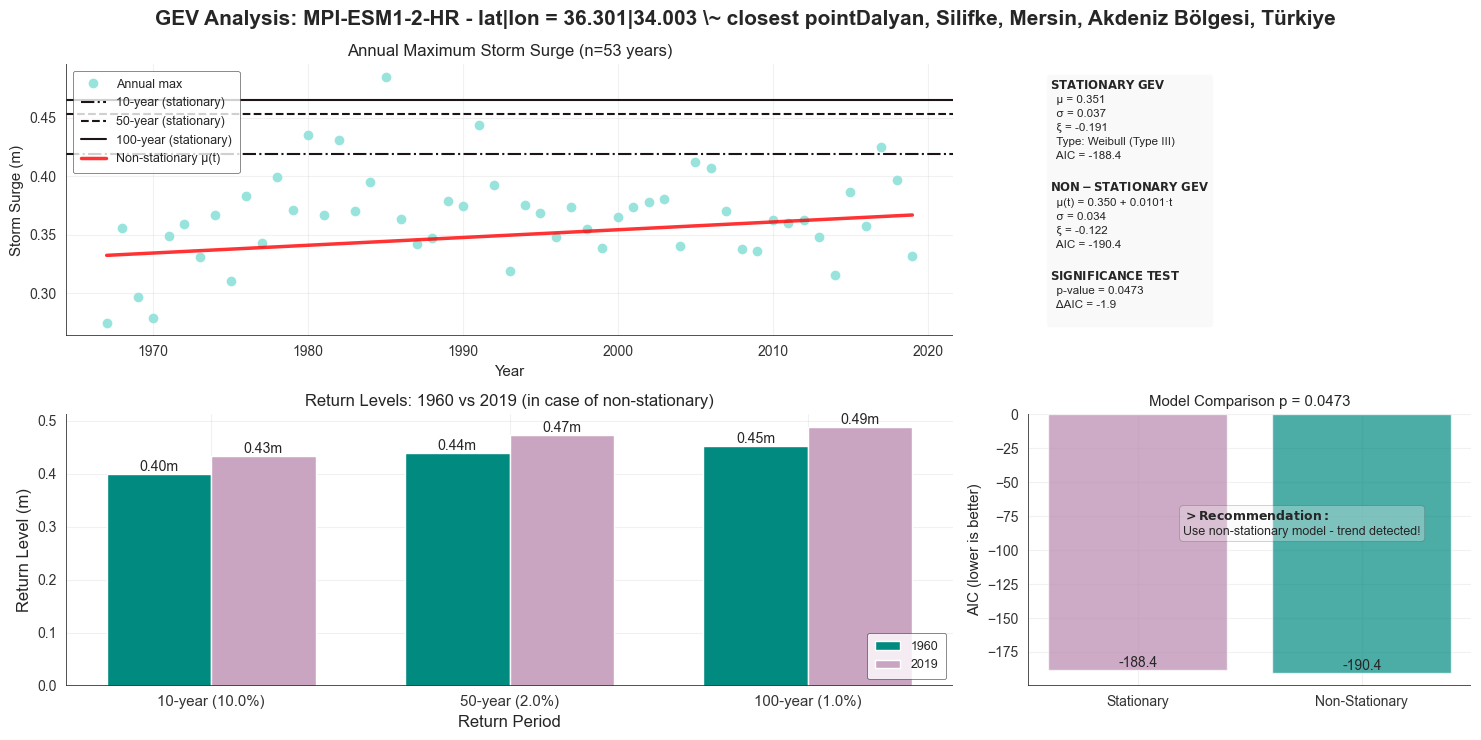

In [ ]:
ls_messages = []
print_msg = True

if result_display:
    ls_messages = ut.adding_plot_and_text("\n" + "="*100, ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"RESULTS for {example_model} - {location_choice}", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text("="*100, ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"\nAnnual maxima: {len(result_display['annual_maxima'])} years", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"Observations per year: ~2 (from ensemble members)", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"Total data points for GEV: {result_display['gev_stationary']['n_obs']}", ls_messages, print_msg)

    ls_messages = ut.adding_plot_and_text("\nSTATIONARY GEV", ls_messages, print_msg)
    stat = result_display['gev_stationary']
    ls_messages = ut.adding_plot_and_text(f"  μ (location) = {stat['location']:.3f}", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"  σ (scale) = {stat['scale']:.3f}", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"  ξ (shape) = {stat['shape']:.3f}", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"  Type: {stat['dist_type']}", ls_messages, print_msg)

    if result_display['gev_nonstationary']:
        ls_messages = ut.adding_plot_and_text("\nNON-STATIONARY GEV", ls_messages, print_msg)
        nonstat = result_display['gev_nonstationary']
        ls_messages = ut.adding_plot_and_text(f"  μ(t) = {nonstat['mu0']:.3f} + {nonstat['mu1']:.4f}·t", ls_messages, print_msg)
        ls_messages = ut.adding_plot_and_text(f"  Trend = {nonstat['mu1'] * nonstat['years_std']:.4f} m/year", ls_messages, print_msg)

    if result_display['model_comparison']:
        ls_messages = ut.adding_plot_and_text("\nMODEL COMPARISON", ls_messages, print_msg)
        comp = result_display['model_comparison']
        ls_messages = ut.adding_plot_and_text(f"  p-value: {comp['p_value']:.4f}", ls_messages, print_msg)
        ls_messages = ut.adding_plot_and_text(f"  Decision: {comp['decision']}", ls_messages, print_msg)
        ls_messages = ut.adding_plot_and_text(f"  → {comp['recommendation']}", ls_messages, print_msg)

    # Store messages (GEV analysis parameters) as txt
    today_ = str(datetime.today().date().isoformat())
    save_path = path_export + today_
    Path(save_path).mkdir(parents=True, exist_ok=True)            
    country = result_display['location info'].split(',')[-1].strip()
    lat_str = str(round(float(result_display['location'][0]), 3))
    lon_str = str(round(float(result_display['location'][1]),3))
    
    with open(save_path + f"/GEVanalysis_{example_model}_{country}_{lat_str}|{lon_str}_{today_}.txt", 'w') as f:
        f.write('\n'.join(ls_messages))
    
    print("\nVISUALIZE RESULTS")
    dbplt.plot_analysis(
        results=results, 
        model=example_model, 
        lat_lon_tuple=result_display['location'], 
        location_info=result_display['location info'],
        periods_evolution = plot_period_evolution,
        box_parameters_x=0.05, box_parameters_y=0.95,
        width_bar_returns=0.35,
        leg_comparison_x=0.35, leg_comparison_y=0.65, linespace=1.5,
        save_path = save_path,
        color_markers='#99E3DDFF', 
        colors_trends='#1D141BFF', 
        colors_models=['#B887ADFF', '#008A80FF'],
        colors_return_levels=['#008A80FF','#CAA5C2FF'],
        bbox_color='#F5F5F5FF',
        axes_color='#333333', 
        linestyle_trends=['dashdot', 'dashed', 'solid'], 
        fontsize=12, figsize=(15, 7.5),
    )

#### Annual Maximum Storm Surge

In [ ]:
result = results[example_model][result_display['location']]

fig1, ax1 = plt.subplots(figsize=(13, 3.5))
dbplt.plot_annual_max_with_trends(
        annual_max=result['annual_maxima'], 
        result=result,
        nonstat=result['gev_nonstationary'],
        comp=result['model_comparison'],
        colors_trends='#333333', 
        linestyle_trends=['solid', 'dashdot', 'dashed'], 
        axes_color='#333333', 
        color_markers='#99E3DDFF', ms=6, fontsize=15, ax=ax1, 
        )